In [7]:
%pip install openai
!pip install decord


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement decord (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for decord


In [3]:
from IPython.display import display, Image, Audio

import cv2
import base64
import time
from openai import OpenAI
import os

In [3]:
# https://cookbook.openai.com/examples/gpt_with_vision_for_video_understanding

In [ ]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", ""))

## my dataset

In [6]:
from data_load import PHOLPhysicsDataset
from torch.utils.data import DataLoader
import torch

# Dataset configuration
# root = "/data/scratch/eez086/phlop/data/"
root = "/Users/Marichka/Studing/Uni/Project/Iran/PHLOP/generated/"
dataset = PHOLPhysicsDataset(root=root, include_qa=True)

# DataLoader with proper collate function
def collate_fn(batch):
    return {
        'scene_id': [item['scene_id'] for item in batch],
        'video': torch.stack([item['video'] for item in batch]),
        'qa': [item['qa'] for item in batch],
        'physical_props': [item['physical_props'] for item in batch],
        'taxonomy': [item['taxonomy'] for item in batch]
    }

dataloader = DataLoader(dataset, 
                       batch_size=1, 
                       shuffle=True,
                       collate_fn=collate_fn)

ModuleNotFoundError: No module named 'decord'

## Test

In [8]:
# video_path = "/user/i/iran/ObjectStateResearch/unzipped/3/simulation_objects.mp4" 
video_path = "dataset/unzipped/3/simulation_objects.mp4"
video_path = "/data/scratch/eez086/phlop/data/3/simulation_objects.mp4"
question = "Did a collision happen in the video?"

In [9]:
video_path

'/data/scratch/eez086/phlop/data/3/simulation_objects.mp4'

In [10]:
video = cv2.VideoCapture(video_path)

base64Frames = []
while video.isOpened():
    success, frame = video.read()
    if not success:
        break
    _, buffer = cv2.imencode(".jpg", frame)
    base64Frames.append(base64.b64encode(buffer).decode("utf-8"))

video.release()
print(len(base64Frames), "frames read.")

376 frames read.


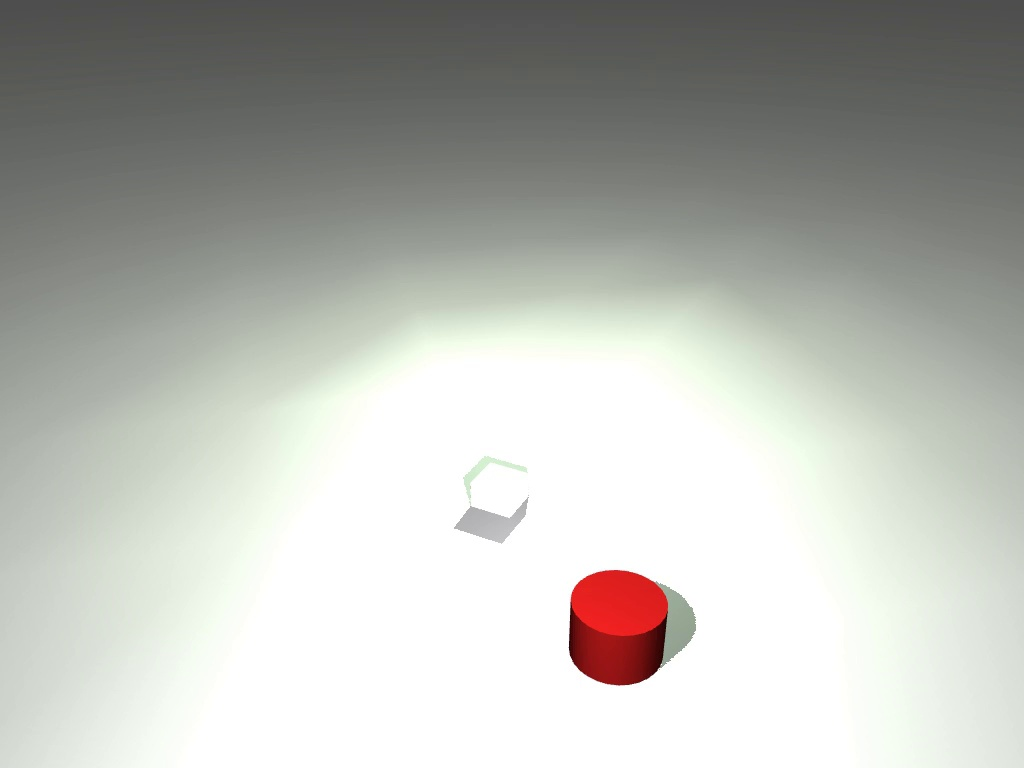

In [11]:
display_handle = display(None, display_id=True)
for img in base64Frames:
    display_handle.update(Image(data=base64.b64decode(img.encode("utf-8"))))
    time.sleep(0.025)

In [12]:
response = client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": (
                        # question
                        # "what type collision happened - elastic or inelastic?"
                        # "How does friction cause an object to stop moving?"
                        # "Which object experienced elastic vs. inelastic collisions"
                        # "Which object has the biggest velocity? what is it?"
                        # "which object is heavier in the collision?"
                        "how many collisions happened in the video?"
                        # "what cause "
                        # """
                        # what cause white box to stop, given that it was: 
                        #     category: Environmental Interactions,
                        #     subcategory: Friction-Induced Events,
                        #     labels: [Sliding with Friction]
                        # """
                    )
                },
                *[
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{frame}"
                    }
                    for frame in base64Frames[0::25]
                ]
            ]
        }
    ],
)

print(response.output_text)

There was one collision in the video. The collision happens between the white cube and the red ball. The red cylinder and the red ball do not collide.


In [13]:
import os

TARGET_DIR = "/data/scratch/eez086/phlop/data"

count = sum(
    1
    for name in os.listdir(TARGET_DIR)
    if os.path.isdir(os.path.join(TARGET_DIR, name))
)
print(f"Found {count} folders in {TARGET_DIR}")


Found 1000 folders in /data/scratch/eez086/phlop/data
